In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

In [6]:
# 1. Cruzando reservas com tipos de quarto e unidades
df_revpar = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_revpar = df_revpar.merge(df_unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade', how='left')



In [7]:
# 2. Calculando a Receita Total gerada por unidade nas reservas disponíveis
receita_unidade = df_revpar.groupby(['id_unidade', 'nome_unidade', 'num_quartos_total'])['qtd_diarias'].apply(lambda x: (x * df_revpar.loc[x.index, 'valor_diaria_base']).sum()).reset_index(name='receita_total_quartos')

# Calculando o total de dias distintos na base para estimar a capacidade do período da amostra
df_revpar['data_checkin'] = pd.to_datetime(df_revpar['data_checkin'], errors='coerce')
dias_amostra = (df_revpar['data_checkin'].max() - df_revpar['data_checkin'].min()).days
if dias_amostra <= 0: dias_amostra = 1



In [8]:
# 3. Calculando o RevPAR da amostra: Receita Total / (Quartos Totais * Dias da Amostra)
receita_unidade['quartos_disponiveis_total'] = receita_unidade['num_quartos_total'] * dias_amostra
receita_unidade['revpar_amostra'] = receita_unidade['receita_total_quartos'] / receita_unidade['quartos_disponiveis_total']



In [9]:
# 4. Calculando a Avaliação Média dos Hóspedes por Unidade
media_avaliacao = df_revpar.groupby('id_unidade')['avaliacao_hospede'].mean().reset_index(name='avaliacao_media')



In [10]:
# 5. Juntando os indicadores em uma única tabela analítica
tabela_analise = receita_unidade.merge(media_avaliacao, on='id_unidade')

# Exibindo a tabela formatada
tabela_exibicao = tabela_analise[['nome_unidade', 'revpar_amostra', 'avaliacao_media']].sort_values(by='revpar_amostra', ascending=False)
tabela_exibicao.columns = ['Unidade', 'RevPAR (Amostra)', 'Avaliação Média']
tabela_exibicao['RevPAR (Amostra)'] = tabela_exibicao['RevPAR (Amostra)'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_exibicao['Avaliação Média'] = tabela_exibicao['Avaliação Média'].apply(lambda x: f"{x:.2f}")

display(tabela_exibicao)



,Unidade,RevPAR (Amostra),Avaliação Média
3,NaraHoteis Santa Teresa,"R$ 15,04",8.04
11,NaraHoteis Mangaratiba,"R$ 12,79",7.74
8,NaraHoteis Friburgo,"R$ 12,77",8.03
5,NaraHoteis Nova Iguaçu Park,"R$ 12,43",7.98
7,NaraHoteis Teresópolis,"R$ 11,34",8.10
9,NaraHoteis Paraty,"R$ 9,71",7.78
6,NaraHoteis Petrópolis,"R$ 9,46",7.97
0,NaraHoteis Ipanema,"R$ 7,31",8.12
10,NaraHoteis Angra dos Reis,"R$ 6,74",7.87
1,NaraHoteis Barra da Tijuca,"R$ 5,39",7.89


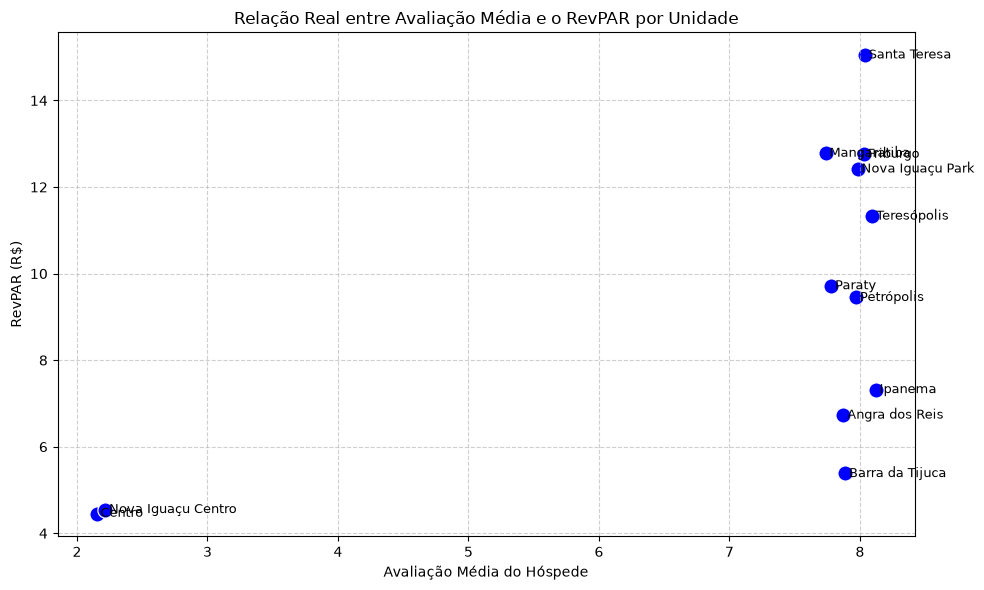

In [12]:
# Gráfico de Dispersão limpo, apenas com os pontos reais (sem a projeção errada)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_analise, x='avaliacao_media', y='revpar_amostra', s=120, color='b')

# Adicionando o nome de cada unidade ao lado do seu respectivo ponto para facilitar a leitura
for i in range(len(tabela_analise)):
    plt.text(tabela_analise['avaliacao_media'].iloc[i] + 0.03, 
             tabela_analise['revpar_amostra'].iloc[i], 
             tabela_analise['nome_unidade'].iloc[i].replace('NaraHoteis ', ''), 
             fontsize=9, va='center')

plt.title('Relação Real entre Avaliação Média e o RevPAR por Unidade')
plt.xlabel('Avaliação Média do Hóspede')
plt.ylabel('RevPAR (R$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Análise de Desempenho e Satisfação

Correlação Direta no Topo: Unidades como NaraHoteis Santa Teresa (RevPAR de R$ 15,04) e Teresópolis (RevPAR de R$ 11,34) lideram a geração de receita e sustentam avaliações sólidas acima de 8.0, validando que a boa reputação atrai hóspedes de maior valor.

O Diagnóstico Crítico das Unidades Centrais: NaraHoteis Centro e Nova Iguaçu Centro não sofrem apenas com baixa receita (RevPAR abaixo de R$ 4,50); elas apresentam notas de avaliação extremamente baixas (2,15 e 2,22).

Causa Raiz Explicada: O problema das unidades centrais vai além da precificação. A insatisfação drástica dos hóspedes destrói a taxa de retorno e afunda a ocupação, revelando um problema crítico de qualidade de serviço e gestão operacional.